In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [18]:
mdom_azi = [0, 90, 180, 270, 
            22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5,
            22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5,
             0, 90, 180, 270]

mdom_zen = [33, 33, 33, 33,
            72, 72, 72, 72, 72, 72, 72, 72,
            108, 108, 108, 108, 108, 108, 108, 108,
            147, 147, 147, 147]

def spherical_to_cartesian(az, zen):
    az = az*np.pi/180
    zen = zen *np.pi/180
    x = np.cos(az)*np.sin(zen)
    y = np.sin(az)*np.sin(zen)
    z = np.cos(zen)
    return [x,y,z]

def calculate_dot_products(df, mdom_azi, mdom_zen, pmt_index):

    pmt_dirs = spherical_to_cartesian(mdom_azi[pmt_index], mdom_zen[pmt_index])
    #pmt_0 = [0, 0, 0]
    dot_products = []
    pmt_str = 'PMT'+str(pmt_index)
    if pmt_index == 23:
        pmt_str = 'PMT23 '
    for i in range(len(df[pmt_str])):
        df[pmt_str][i]
        az = df['# phi'][i]
        zen = df['theta'][i]
        ray_dir = spherical_to_cartesian(az, zen)
        dot_product = ray_dir[0]*pmt_dirs[0] + ray_dir[1]*pmt_dirs[1] + ray_dir[2]*pmt_dirs[2]
        dot_products.append(dot_product)
    return dot_products

/tmp/ipykernel_42118/1314098748.py:14: RuntimeWarning: invalid value encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta
/tmp/ipykernel_42118/1314098748.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta


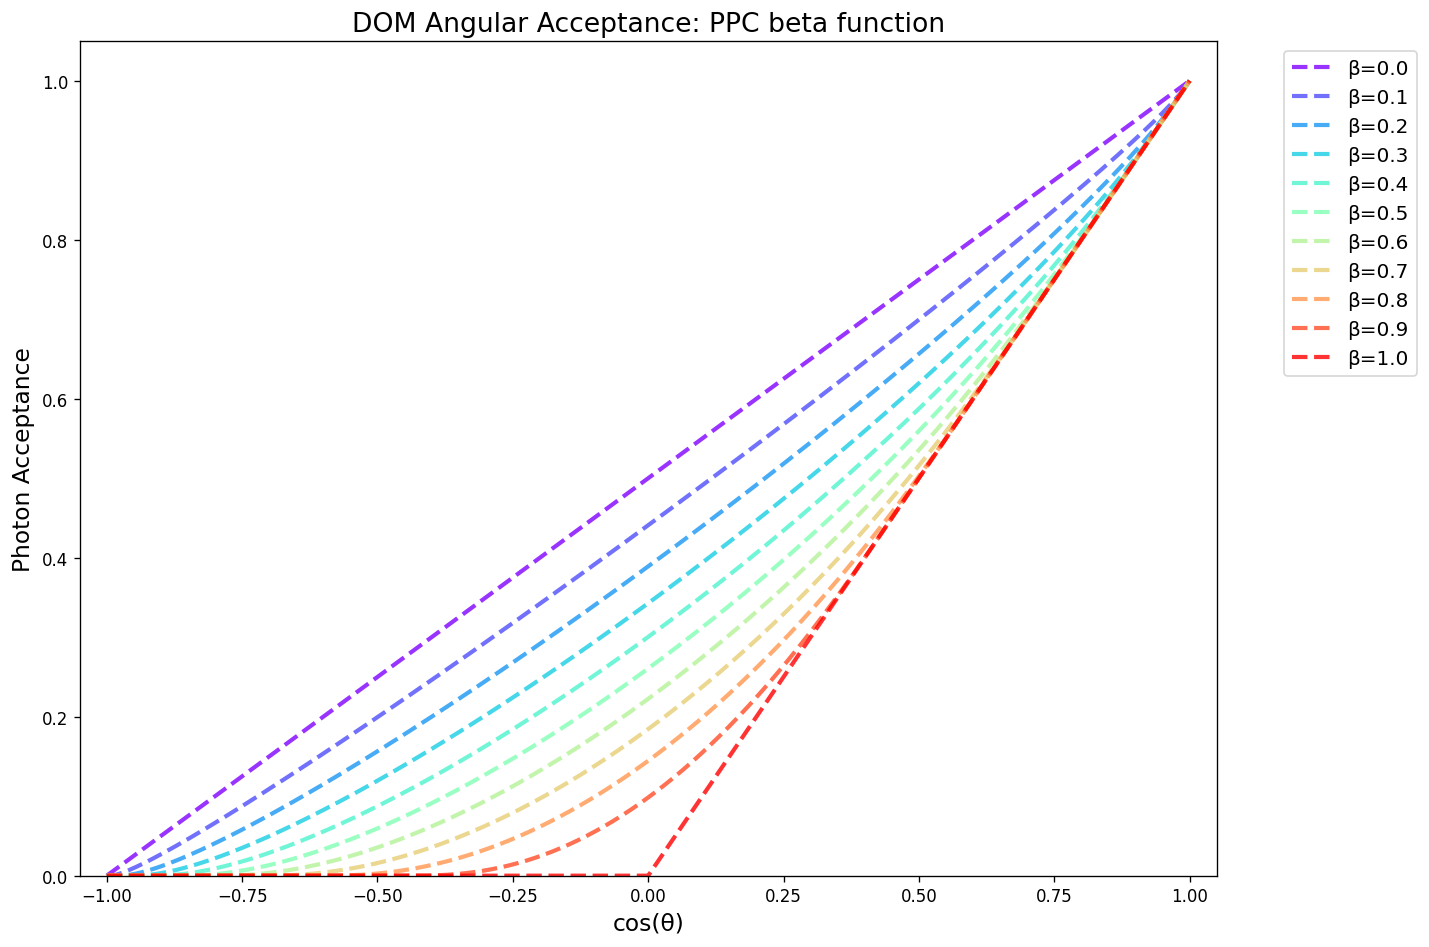

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# angular acceptance
def aS(x):
    al = np.arccos(x)
    return al - np.sin(2 * al) / 2

def f(x, beta):
    sum_val = x if x > 0 else 0
    if beta < 1:
        y = np.sqrt(1 - x**2) / beta
        if y > 1:
            y = 1 / y
            c = 1 - beta**2
            sum_val += (aS(y) / c - aS(y * abs(x) / np.sqrt(c)) * abs(x)) / np.pi
    return sum_val

def error_function(beta, x_data, y_data):
    y_theoretical = np.array([f(x, beta[0]) for x in x_data])
    return np.sum((y_theoretical - y_data)**2)

dir_without_harness = '/home/jack/Downloads/Data/Output/'

OM_names = ['DOM']
wavelength_for_costheta = 400

wvs = np.arange(270, 700, 10)
all_data = {}

for OM_name in OM_names:
    wavelength_data = []
    
    for wv in wvs:
        try:
            om_file = f'{OM_name}_{wv}.txt'
            df = pd.read_csv(dir_without_harness + om_file, delimiter='\t', skiprows=0)
            
            mean_eff = df['total'].mean()
            
            df['cos_theta'] = np.cos(df['theta'] * np.pi / 180)
            
            forward_mean = df[df['cos_theta'] > 0]['total'].mean()
            backward_mean = df[df['cos_theta'] < 0]['total'].mean()
            
            wavelength_data.append({
                'wavelength': wv,
                'mean_effective_area': mean_eff,
                'forward_mean': forward_mean,
                'backward_mean': backward_mean
            })
            
            if wv == wavelength_for_costheta:
                costheta_df = df.copy()
                
        except Exception as e:
            print(f"Error processing {OM_name} at {wv}nm: {e}")
            if wv == wavelength_for_costheta:
                costheta_df = None
    
    all_data[OM_name] = {
        'wavelength_data': pd.DataFrame(wavelength_data),
        'costheta_data': costheta_df
    }

plt.figure(figsize=(12, 8), dpi=120, facecolor='white')


x = np.linspace(-1, 1, 1000)

cmap = plt.cm.rainbow
beta_values = np.arange(0.0, 1.1, 0.1)
colors = cmap(np.linspace(0, 1, len(beta_values)))

for i, beta in enumerate(beta_values):
    f_returns = [f(dot, beta) for dot in x]
    plt.plot(x, f_returns, '--', alpha=0.8, lw=2.5, color=colors[i], label=f'β={beta:.1f}')

plt.ylim(0, 1.05)
plt.xlim(-1.05, 1.05)

plt.xlabel('cos(θ)', fontsize=14)
plt.ylabel('Photon Acceptance', fontsize=14)
plt.title('DOM Angular Acceptance: PPC beta function', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7, color='white')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=12)


plt.tight_layout()
plt.show()

/tmp/ipykernel_42118/1572461175.py:16: RuntimeWarning: invalid value encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta
/tmp/ipykernel_42118/1572461175.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta


mDOM_380.txt
Index(['# phi', 'theta', 'PMT0', 'PMT1', 'PMT2', 'PMT3', 'PMT4', 'PMT5',
       'PMT6', 'PMT7', 'PMT8', 'PMT9', 'PMT10', 'PMT11', 'PMT12', 'PMT13',
       'PMT14', 'PMT15', 'PMT16', 'PMT17', 'PMT18', 'PMT19', 'PMT20', 'PMT21',
       'PMT22', 'PMT23 ', 'total'],
      dtype='object')
mDOM_400.txt
Index(['# phi', 'theta', 'PMT0', 'PMT1', 'PMT2', 'PMT3', 'PMT4', 'PMT5',
       'PMT6', 'PMT7', 'PMT8', 'PMT9', 'PMT10', 'PMT11', 'PMT12', 'PMT13',
       'PMT14', 'PMT15', 'PMT16', 'PMT17', 'PMT18', 'PMT19', 'PMT20', 'PMT21',
       'PMT22', 'PMT23 ', 'total'],
      dtype='object')
mDOM_420.txt
Index(['# phi', 'theta', 'PMT0', 'PMT1', 'PMT2', 'PMT3', 'PMT4', 'PMT5',
       'PMT6', 'PMT7', 'PMT8', 'PMT9', 'PMT10', 'PMT11', 'PMT12', 'PMT13',
       'PMT14', 'PMT15', 'PMT16', 'PMT17', 'PMT18', 'PMT19', 'PMT20', 'PMT21',
       'PMT22', 'PMT23 ', 'total'],
      dtype='object')
mDOM_440.txt
Index(['# phi', 'theta', 'PMT0', 'PMT1', 'PMT2', 'PMT3', 'PMT4', 'PMT5',
       'PMT6', 'PMT7

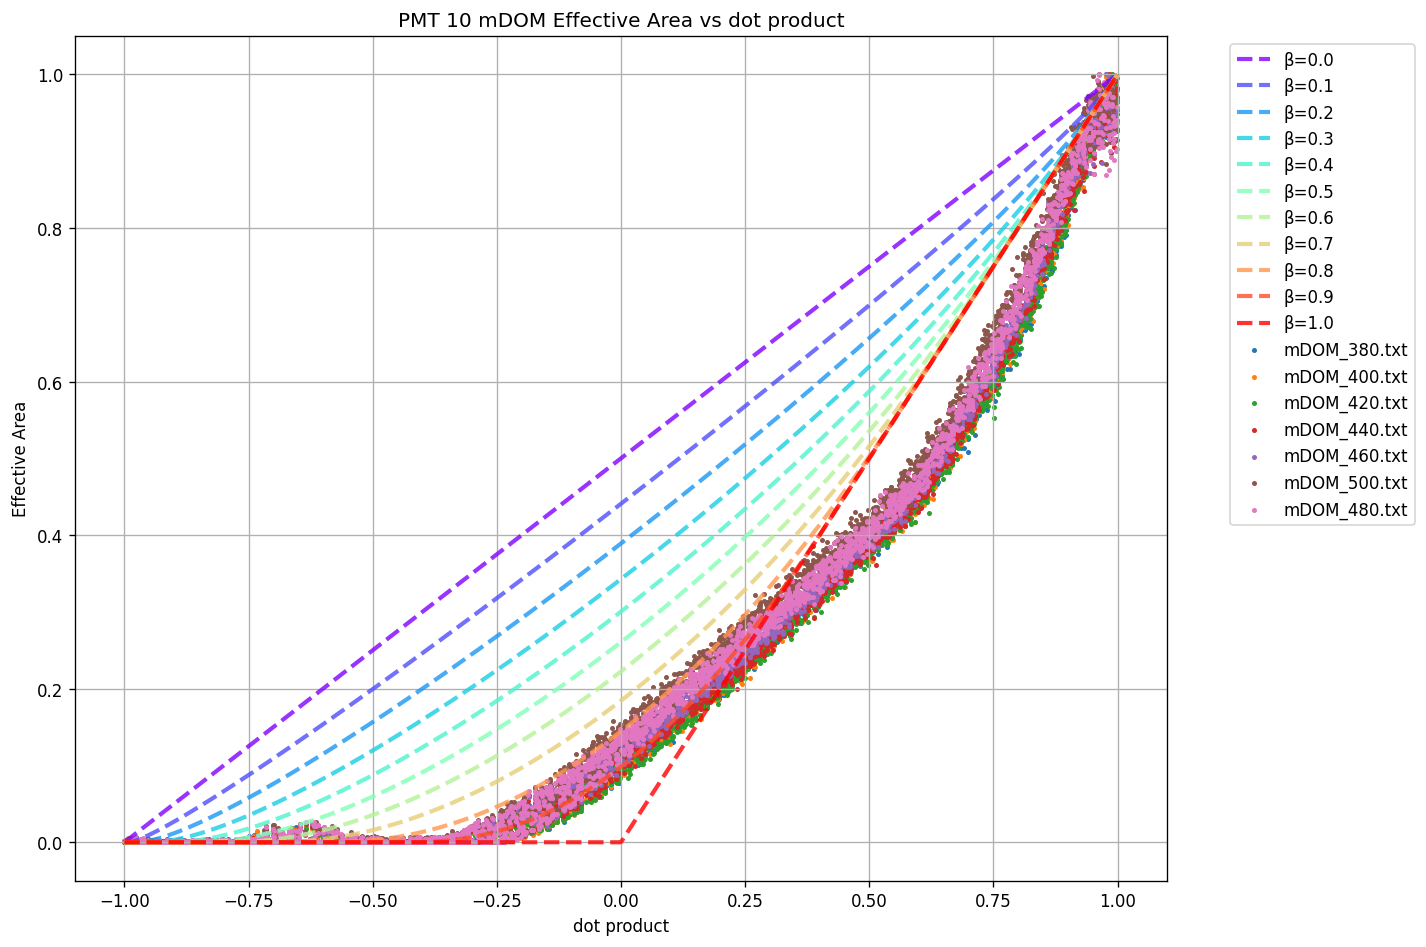

In [20]:



om_files = ['mDOM_380.txt', 'mDOM_400.txt', 'mDOM_420.txt', 'mDOM_440.txt', 'mDOM_460.txt', 'mDOM_500.txt', 'mDOM_480.txt']
dir_without_harness = 'Output_NoHarness'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


def aS(x):
    al = np.arccos(x)
    return al - np.sin(2 * al) / 2

def f(x, beta):
    sum_val = x if x > 0 else 0
    if beta < 1:
        y = np.sqrt(1 - x**2) / beta
        if y > 1:
            y = 1 / y
            c = 1 - beta**2
            sum_val += (aS(y) / c - aS(y * abs(x) / np.sqrt(c)) * abs(x)) / np.pi
    return sum_val

def error_function(beta, x_data, y_data):
    y_theoretical = np.array([f(x, beta[0]) for x in x_data])
    
    return np.sum((y_theoretical - y_data)**2)

dir_without_harness = 'Output_NoHarness/'


wavelength_for_costheta = 400

wvs = np.arange(270, 700, 10)

all_data = {}

for OM_name in OM_names:
    wavelength_data = []
    
    for wv in wvs:
        try:
            om_file = f'{OM_name}_{wv}.txt'
            df = pd.read_csv(dir_without_harness + om_file, delimiter='\t', skiprows=0)
            
            mean_eff = df['total'].mean()
            
            df['cos_theta'] = np.cos(df['theta'] * np.pi / 180)
            
            forward_mean = df[df['cos_theta'] > 0]['total'].mean()
            backward_mean = df[df['cos_theta'] < 0]['total'].mean()
            
            wavelength_data.append({
                'wavelength': wv,
                'mean_effective_area': mean_eff,
                'forward_mean': forward_mean,
                'backward_mean': backward_mean
            })
            
            if wv == wavelength_for_costheta:
                costheta_df = df.copy()
                
        except Exception as e:
            print(f"Error processing {OM_name} at {wv}nm: {e}")
            if wv == wavelength_for_costheta:
                costheta_df = None
    
    all_data[OM_name] = {
        'wavelength_data': pd.DataFrame(wavelength_data),
        'costheta_data': costheta_df
    }

plt.figure(figsize=(12, 8), dpi=120, facecolor='white')


x = np.linspace(-1, 1, 1000)

cmap = plt.cm.rainbow
beta_values = np.arange(0.0, 1.1, 0.1)
colors = cmap(np.linspace(0, 1, len(beta_values)))

for i, beta in enumerate(beta_values):
    f_returns = [f(dot, beta) for dot in x]
    plt.plot(x, f_returns, '--', alpha=0.8, lw=2.5, color=colors[i], label=f'β={beta:.1f}')


for j in range(len(om_files)):
    df = pd.read_csv(dir_without_harness + om_files[j], delimiter='\t', skiprows=0)

    print(om_files[j])
    print(df.columns)

    alpha_val=1
    for i in range(10,11):
        pmt_str = 'PMT' + str(i)
        if i ==23:
            pmt_str = 'PMT23 '

        dot_products = calculate_dot_products(df, mdom_azi, mdom_zen, i)
        alpha_val-=0.02


        plt.scatter(dot_products, df[pmt_str]/np.max(df[pmt_str]), s = 4, alpha = alpha_val, label=om_files[j])

        plt.xlabel('dom product (incident plane wave dot pmt direction)')
        plt.ylabel('effective area')
        np.linspace(-1, 1, len(dot_products))
        plt.legend()


plt.xlabel('dot product')
plt.ylabel('Effective Area')
plt.title('PMT 10 mDOM Effective Area vs dot product')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




/tmp/ipykernel_42118/828989439.py:15: RuntimeWarning: invalid value encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta
/tmp/ipykernel_42118/828989439.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta


mDOM_380.txt
Index(['# phi', 'theta', 'PMT0', 'PMT1', 'PMT2', 'PMT3', 'PMT4', 'PMT5',
       'PMT6', 'PMT7', 'PMT8', 'PMT9', 'PMT10', 'PMT11', 'PMT12', 'PMT13',
       'PMT14', 'PMT15', 'PMT16', 'PMT17', 'PMT18', 'PMT19', 'PMT20', 'PMT21',
       'PMT22', 'PMT23 ', 'total'],
      dtype='object')
mDOM_400.txt
Index(['# phi', 'theta', 'PMT0', 'PMT1', 'PMT2', 'PMT3', 'PMT4', 'PMT5',
       'PMT6', 'PMT7', 'PMT8', 'PMT9', 'PMT10', 'PMT11', 'PMT12', 'PMT13',
       'PMT14', 'PMT15', 'PMT16', 'PMT17', 'PMT18', 'PMT19', 'PMT20', 'PMT21',
       'PMT22', 'PMT23 ', 'total'],
      dtype='object')
mDOM_420.txt
Index(['# phi', 'theta', 'PMT0', 'PMT1', 'PMT2', 'PMT3', 'PMT4', 'PMT5',
       'PMT6', 'PMT7', 'PMT8', 'PMT9', 'PMT10', 'PMT11', 'PMT12', 'PMT13',
       'PMT14', 'PMT15', 'PMT16', 'PMT17', 'PMT18', 'PMT19', 'PMT20', 'PMT21',
       'PMT22', 'PMT23 ', 'total'],
      dtype='object')
mDOM_440.txt
Index(['# phi', 'theta', 'PMT0', 'PMT1', 'PMT2', 'PMT3', 'PMT4', 'PMT5',
       'PMT6', 'PMT7

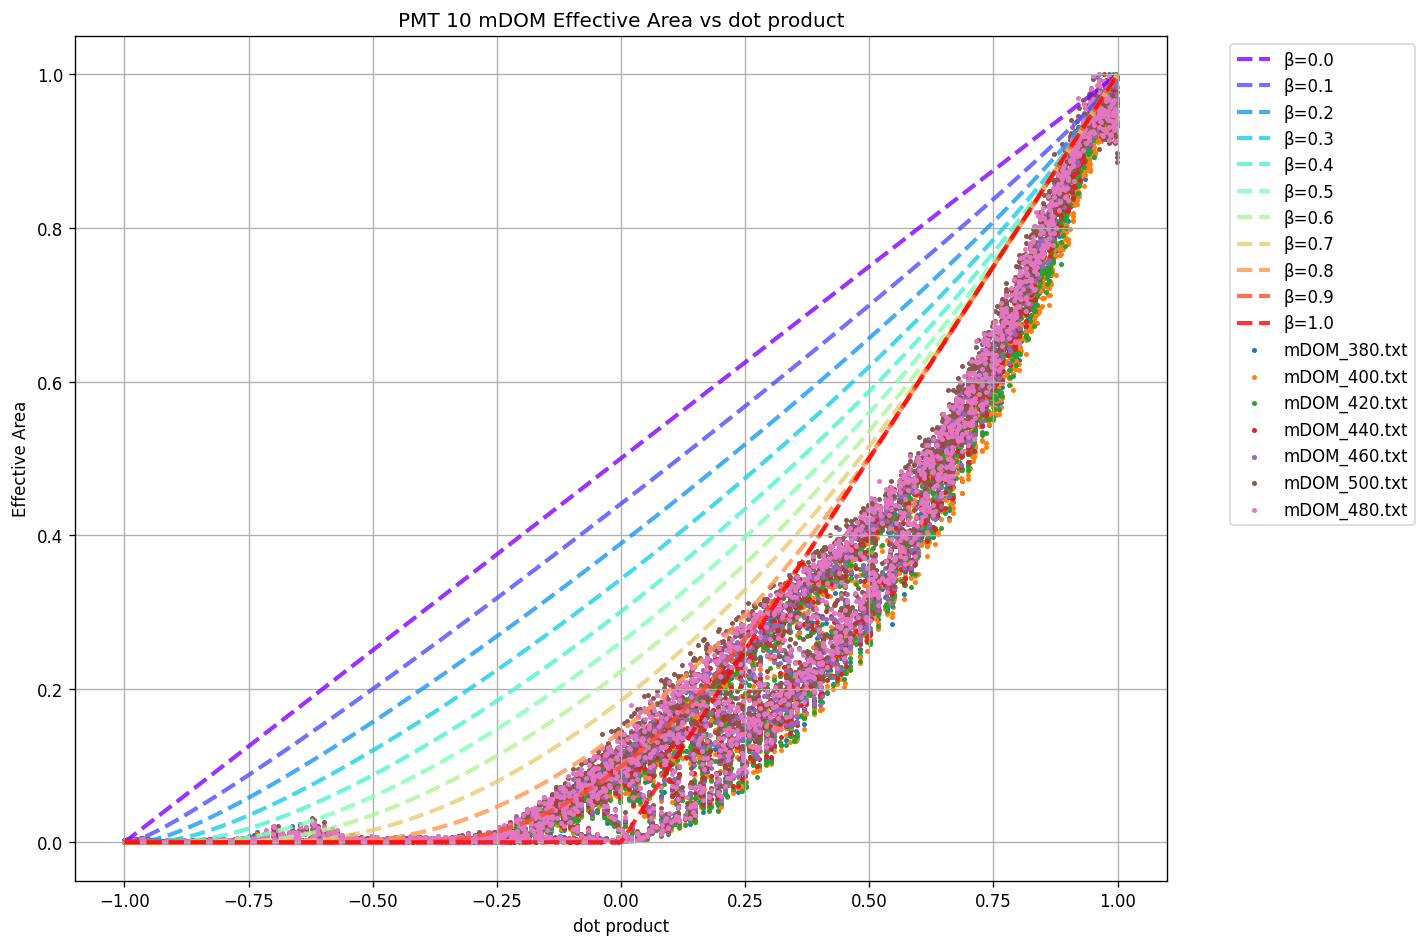

In [21]:



om_files = ['mDOM_380.txt', 'mDOM_400.txt', 'mDOM_420.txt', 'mDOM_440.txt', 'mDOM_460.txt', 'mDOM_500.txt', 'mDOM_480.txt']
dir_without_harness = 'Output_WithHarness/'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def aS(x):
    al = np.arccos(x)
    return al - np.sin(2 * al) / 2

def f(x, beta):
    sum_val = x if x > 0 else 0
    if beta < 1:
        y = np.sqrt(1 - x**2) / beta
        if y > 1:
            y = 1 / y
            c = 1 - beta**2
            sum_val += (aS(y) / c - aS(y * abs(x) / np.sqrt(c)) * abs(x)) / np.pi
    return sum_val

def error_function(beta, x_data, y_data):
    y_theoretical = np.array([f(x, beta[0]) for x in x_data])
    
    return np.sum((y_theoretical - y_data)**2)

dir_without_harness = 'Output_WithHarness/'


wavelength_for_costheta = 400

wvs = np.arange(270, 700, 10)

all_data = {}

for OM_name in OM_names:
    wavelength_data = []
    
    for wv in wvs:
        try:
            om_file = f'{OM_name}_{wv}.txt'
            df = pd.read_csv(dir_without_harness + om_file, delimiter='\t', skiprows=0)
            
            mean_eff = df['total'].mean()
            
            df['cos_theta'] = np.cos(df['theta'] * np.pi / 180)
            
            forward_mean = df[df['cos_theta'] > 0]['total'].mean()
            backward_mean = df[df['cos_theta'] < 0]['total'].mean()
            
            wavelength_data.append({
                'wavelength': wv,
                'mean_effective_area': mean_eff,
                'forward_mean': forward_mean,
                'backward_mean': backward_mean
            })
            
            if wv == wavelength_for_costheta:
                costheta_df = df.copy()
                
        except Exception as e:
            print(f"Error processing {OM_name} at {wv}nm: {e}")
            if wv == wavelength_for_costheta:
                costheta_df = None
    all_data[OM_name] = {
        'wavelength_data': pd.DataFrame(wavelength_data),
        'costheta_data': costheta_df
    }

plt.figure(figsize=(12, 8), dpi=120, facecolor='white')


x = np.linspace(-1, 1, 1000)

cmap = plt.cm.rainbow
beta_values = np.arange(0.0, 1.1, 0.1)
colors = cmap(np.linspace(0, 1, len(beta_values)))

for i, beta in enumerate(beta_values):
    f_returns = [f(dot, beta) for dot in x]
    plt.plot(x, f_returns, '--', alpha=0.8, lw=2.5, color=colors[i], label=f'β={beta:.1f}')


for j in range(len(om_files)):
    df = pd.read_csv(dir_without_harness + om_files[j], delimiter='\t', skiprows=0)

    print(om_files[j])
    print(df.columns)

    alpha_val=1
    for i in range(10,11):
        pmt_str = 'PMT' + str(i)
        if i ==23:
            pmt_str = 'PMT23 '

        dot_products = calculate_dot_products(df, mdom_azi, mdom_zen, i)
        alpha_val-=0.02


        plt.scatter(dot_products, df[pmt_str]/np.max(df[pmt_str]), s = 4, alpha = alpha_val, label=om_files[j])

        plt.xlabel('dom product (incident plane wave dot pmt direction)')
        plt.ylabel('effective area')
        np.linspace(-1, 1, len(dot_products))
        plt.legend()


plt.xlabel('dot product')
plt.ylabel('Effective Area')
plt.title('PMT 10 mDOM Effective Area vs dot product')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




/tmp/ipykernel_42118/123095598.py:16: RuntimeWarning: invalid value encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta
/tmp/ipykernel_42118/123095598.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta
/tmp/ipykernel_42118/123095598.py:16: RuntimeWarning: invalid value encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta
/tmp/ipykernel_42118/123095598.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  y = np.sqrt(1 - x**2) / beta
/tmp/ipykernel_42118/123095598.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


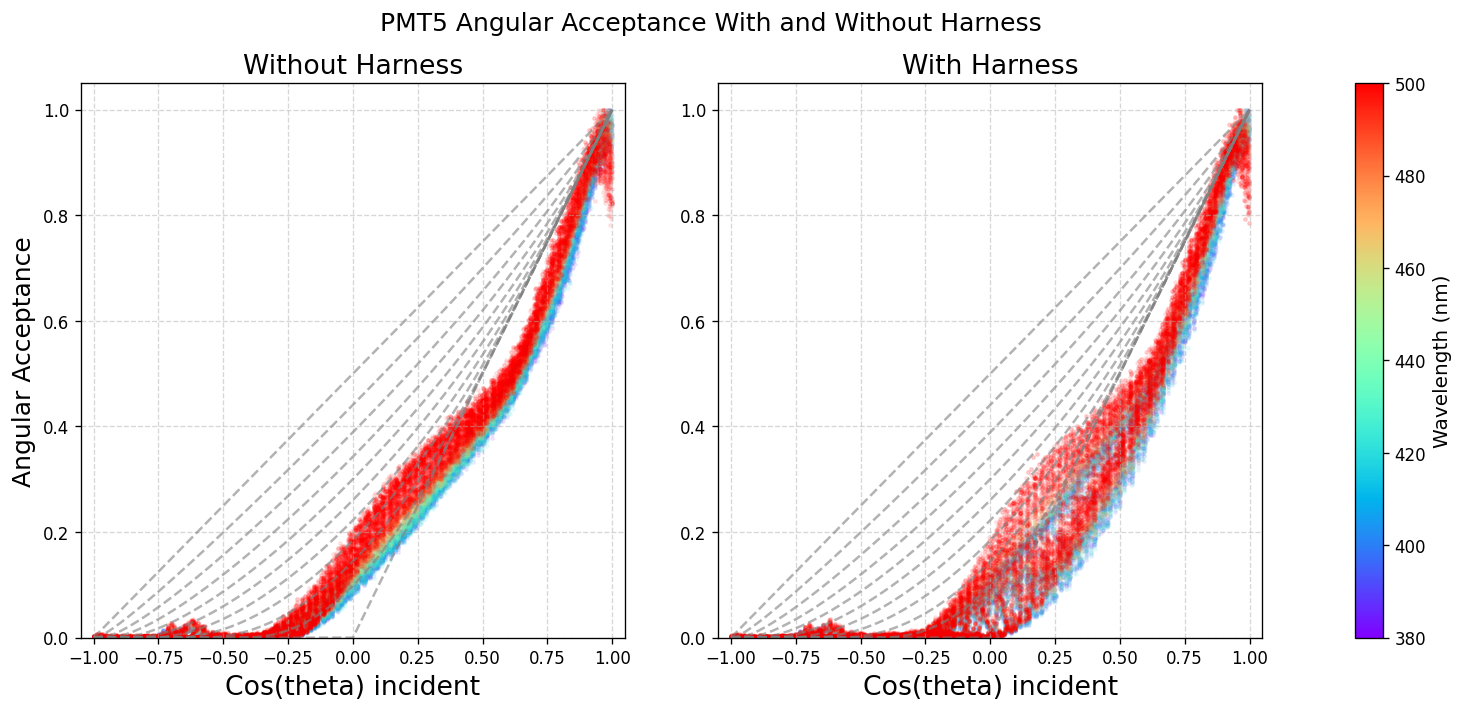

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.gridspec import GridSpec


def aS(x):
    al = np.arccos(x)
    return al - np.sin(2 * al) / 2

def f(x, beta):
    sum_val = x if x > 0 else 0
    if beta < 1:
        y = np.sqrt(1 - x**2) / beta
        if y > 1:
            y = 1 / y
            c = 1 - beta**2
            sum_val += (aS(y) / c - aS(y * abs(x) / np.sqrt(c)) * abs(x)) / np.pi
    return sum_val

om_files = ['mDOM_380.txt', 'mDOM_390.txt', 'mDOM_400.txt', 'mDOM_410.txt', 'mDOM_420.txt', 'mDOM_440.txt', 'mDOM_460.txt', 'mDOM_500.txt', 'mDOM_480.txt', 'mDOM_580.txt', 'mDOM_520.txt', 'mDOM_540.txt', 'mDOM_560.txt', 'mDOM_580.txt', 'mDOM_600.txt']
dirs = {
    'Without Harness': 'Output_NoHarness/',
    'With Harness': 'Output_WithHarness/'
}
cmap = cm.rainbow
norm = plt.Normalize(vmin=380, vmax=500)
colors = {int(name.split('_')[1].split('.')[0]): cmap(norm(int(name.split('_')[1].split('.')[0]))) for name in om_files}
beta_values = np.arange(0.0, 1.1, 0.1)
x = np.linspace(-1, 1, 1000)

fig = plt.figure(figsize=(14, 6), dpi=120)
gs = GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.25)

for idx, (title, directory) in enumerate(dirs.items()):
    ax = fig.add_subplot(gs[idx])

    for om_file in om_files:
        try:
            df = pd.read_csv(directory + om_file, delimiter='\t', skiprows=0)
            wv = int(om_file.split('_')[1].split('.')[0])
            dot_products = calculate_dot_products(df, mdom_azi, mdom_zen, 5)

            pmt_str = 'PMT5'
            if 'PMT5' not in df.columns:
                print(f"{om_file}: PMT10 not found")
                continue

            eff_area = df[pmt_str].values / np.max(df[pmt_str].values)
            ax.scatter(dot_products, eff_area, s=4, alpha=0.08, label=f"{wv} nm", color=colors[wv])
        except Exception as e:
            print(f"Error reading {om_file} in {title}: {e}")
            continue

    for i, beta in enumerate(beta_values):
        f_vals = [f(dot, beta) for dot in x]
        ax.plot(x, f_vals, '--', lw=1.5, alpha=0.6, color='black' if beta == 0.6 else 'grey', 
                label=f'β={beta:.1f}' if idx == 0 else None)

    ax.set_title(f'{title}', fontsize=16)
    ax.set_xlabel('Cos(theta) incident',fontsize=16)
    if idx == 0:
        ax.set_ylabel('Angular Acceptance', fontsize=15)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)

cbar_ax = fig.add_subplot(gs[2])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('Wavelength (nm)', fontsize=12)

plt.suptitle('PMT5 Angular Acceptance With and Without Harness', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()
